<a href="https://colab.research.google.com/github/kevinquiosc-rgb/Projectos_Kevin/blob/main/Proyecto_Proyeccion_Ventas_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROYECCION DE VENTAS - PROYECTO LABORAL EN MI ULTIMO EMPLEO**

Durante el ejercicio de mi labor como analista de bussiness inteligence surgió la oportunidad de elaborar un pronostico de ventas anual el cual hasta antes de mi contratacion tenia un muy mal % de cumplimiento (entre el 50% y 70%) por lo que me advoque a generarlo utilizando herramientas de mi conocimiento estadistico, en especial las series temporales ya que son perfectamente viables cuando no se tiene mucha referencia de los clientes que vienen como leads de una pagina web que ofrece subscripciones con este metodo logre una tasa de acierto del 90 a 95% promedio tanto para las ventas nuevas asi como para las renovaciones anuales.

Considerando que los leads se mantenian en tendencia constante ademas la pandemia no habia generado un cambio significativo al ritmo de ventas. Decidi aplicar el enfoque de series temporales con un horizonte de 5 años + 6 meses.

El siguiente Notebook señala el analisis realizado y el pronostico final obtenido por el metodo de series de tiempo y el metodo triple suavizado exponencial.

# **CARGA DE DATOS Y PREVIEW**

Todos los datos fueron tomados de la bbdd en SQL del sistema (CRM)

Select año,mes,region,Venta,Precio,Plan,AreaVenta from ventas where idañomes between 201900 and 202413

In [ ]:
## CARGA DE DRIVE
# Nos vinculamos a nuestro drive, para poder usar los datos
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
## IMPORTANDO LIBRERIAS
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import sqrt
import seaborn as sns
from datetime import datetime
from pandas import Series
from matplotlib import pyplot

In [ ]:
df.info()

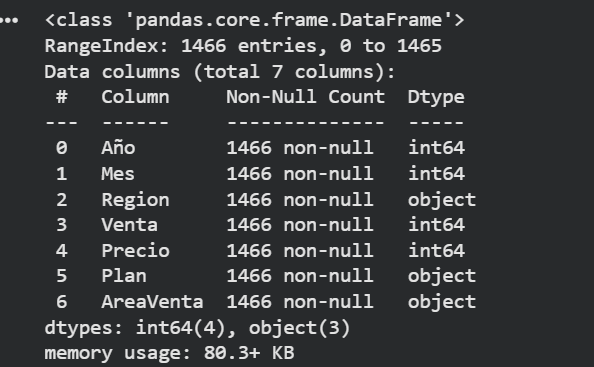

In [ ]:
df.head()

In [ ]:
df['Fecha'] = df['Año'].map(str) +"-" + df['Mes'].map(str) +"-" + "01"

In [ ]:
df.tail()

In [ ]:
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m-%d')


# Analisis Exploratorio de datos

Luego de tener un primer vistado de los datos realice un analisis de total de ventas por region, plan y evolutivo.

In [ ]:
df.groupby('Region')['Venta'].sum() / df['Venta'].sum()

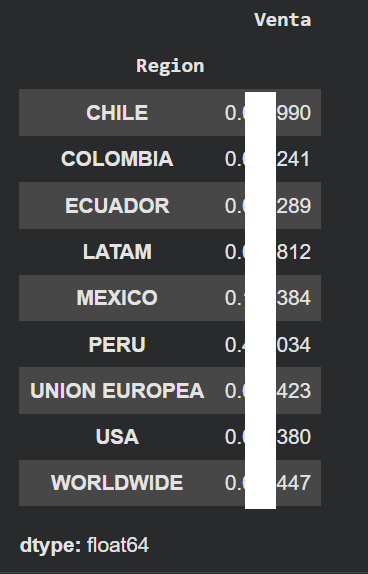

La proporcion de venta por region permite caracterizar el futuro pronostico para poder adecuar la participacion regional final.

In [ ]:
df.groupby('Plan')['Venta'].sum() / df['Venta'].sum()

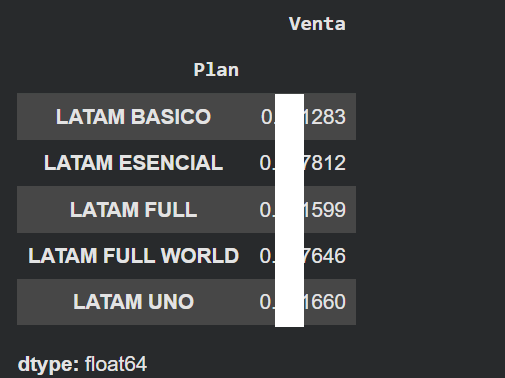

el analisis de proporcion por plan permite establecer la cantidad de planes estimado para caracterizar el pronostico obtenido y los precios asociados a los productos.

In [ ]:
y = df.set_index('Fecha')

In [ ]:
df = df.set_index('Fecha')

In [ ]:
y = y.resample('M').agg({"Venta":'sum'})
y.tail(8)

In [ ]:
fig, ax = plt.subplots(figsize=(15,6))
sns.lineplot(x=y.index.month, y=y.Venta, ax=ax,hue = y.index.year,palette='deep',markers=True, dashes=False ).set(title='Evolutivo de ventas por mes del 2019 a 2024')
plt.show()

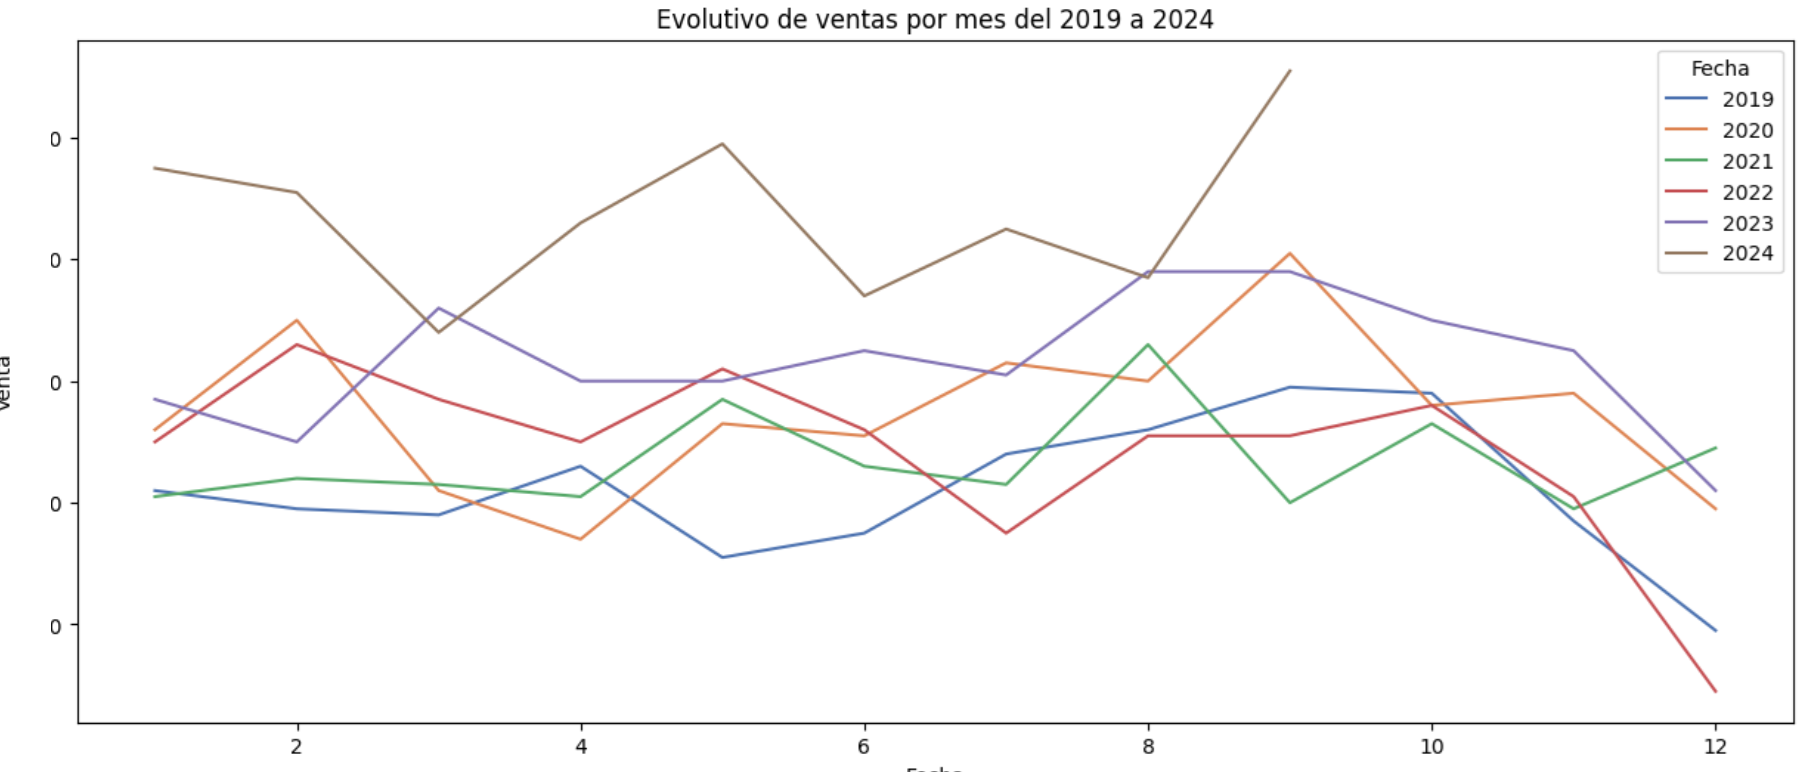

Como se observa la tendencia de ventas año por año evidencia un crecimiento sostenido que inicio el 2023

In [ ]:
# HISTOGRAMA Y DENSIDAD - habria normalidad
pyplot.figure(1)
pyplot.subplot(211)
y.Venta.hist()
pyplot.subplot(212)
y.Venta.plot(kind='kde')
pyplot.show()

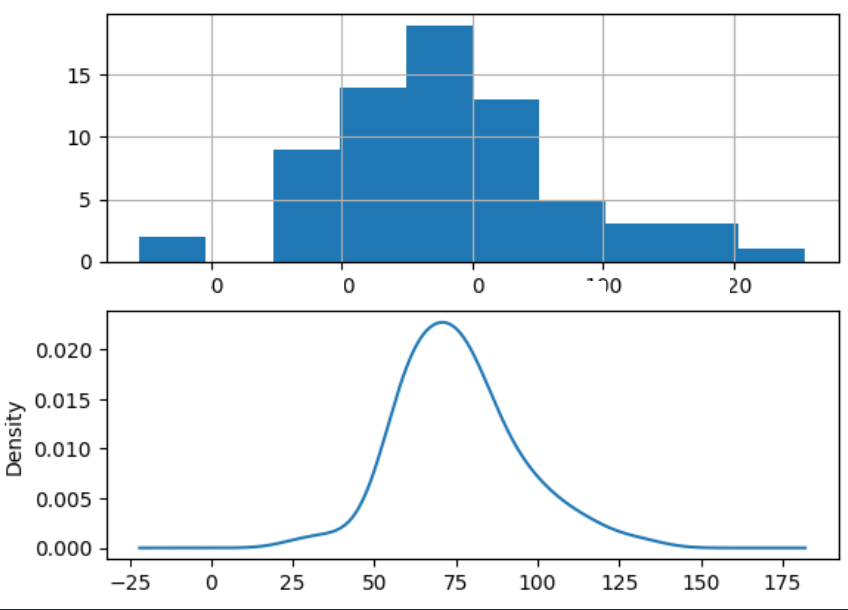

Se evaluo la normalidad de forma grafica en las ventas para saber si podemos aplicar la metodologia de box-jenkins y esta aparentemente existe.

In [ ]:
fig, ax = plt.subplots(figsize=(15,6))
sns.boxplot(x=y.Venta.index.month, y=y.Venta, ax=ax).set(title='Diagrama de cajas de ventas por mes del 2019 a 2024')
plt.show()

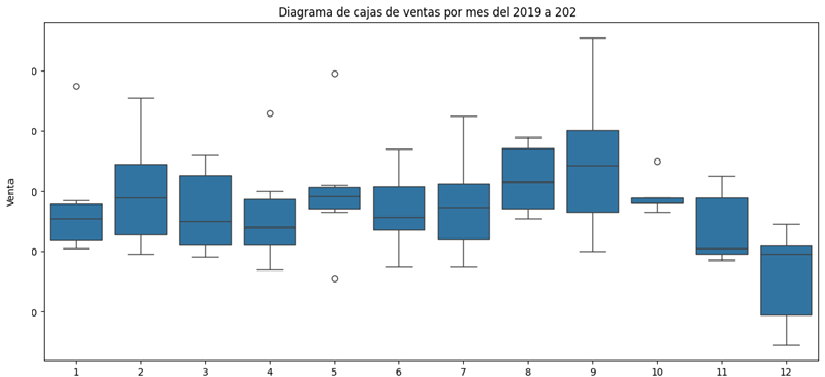

El analisis de cajas nos permite evidenciar tendencias mensuales de acuerdo a la amplitud de las mismas en meses puntuales por ejemplo en el Q4 se evidencia una caida sostenida en los meses noviembre y diciembre ademas evidenciar tambien los meses con mayor variabilidad de ventas como setiembre finalmente nos permite señalar valores atipicos fuera de las cajas para buscar una explicacion puntual y ver si deben ser contabilizados en la construccion del modelo.

In [ ]:
fig, ax = plt.subplots(figsize=(15,6))
sns.boxplot(x=y.Venta.index.year, y=y.Venta, ax=ax).set(title='Diagrama de cajas de ventas por año del 2020 a 2024')
plt.show()

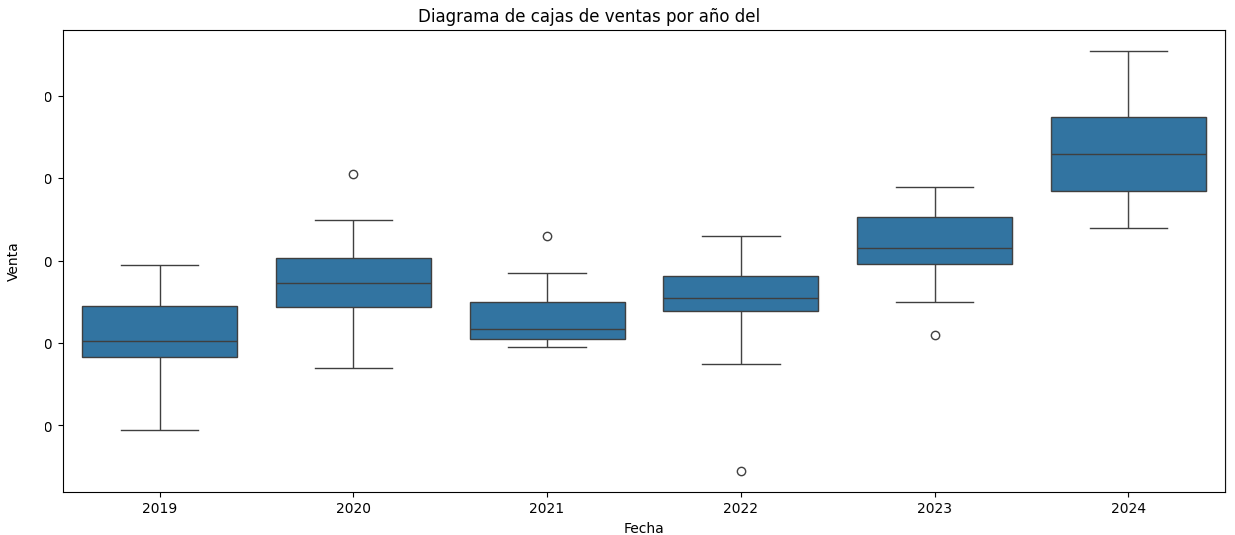

Otra forma de evidenciar la tendencia es poner en cajas y por años y se evicencia el crecimiento sostenido a partir del año 2023.

# **Modelamiento de datos**

In [ ]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib
decomposition = sm.tsa.seasonal_decompose(y, model='aditive')
matplotlib.rcParams['figure.figsize'] = 18, 8
fig = decomposition.plot()
plt.show()

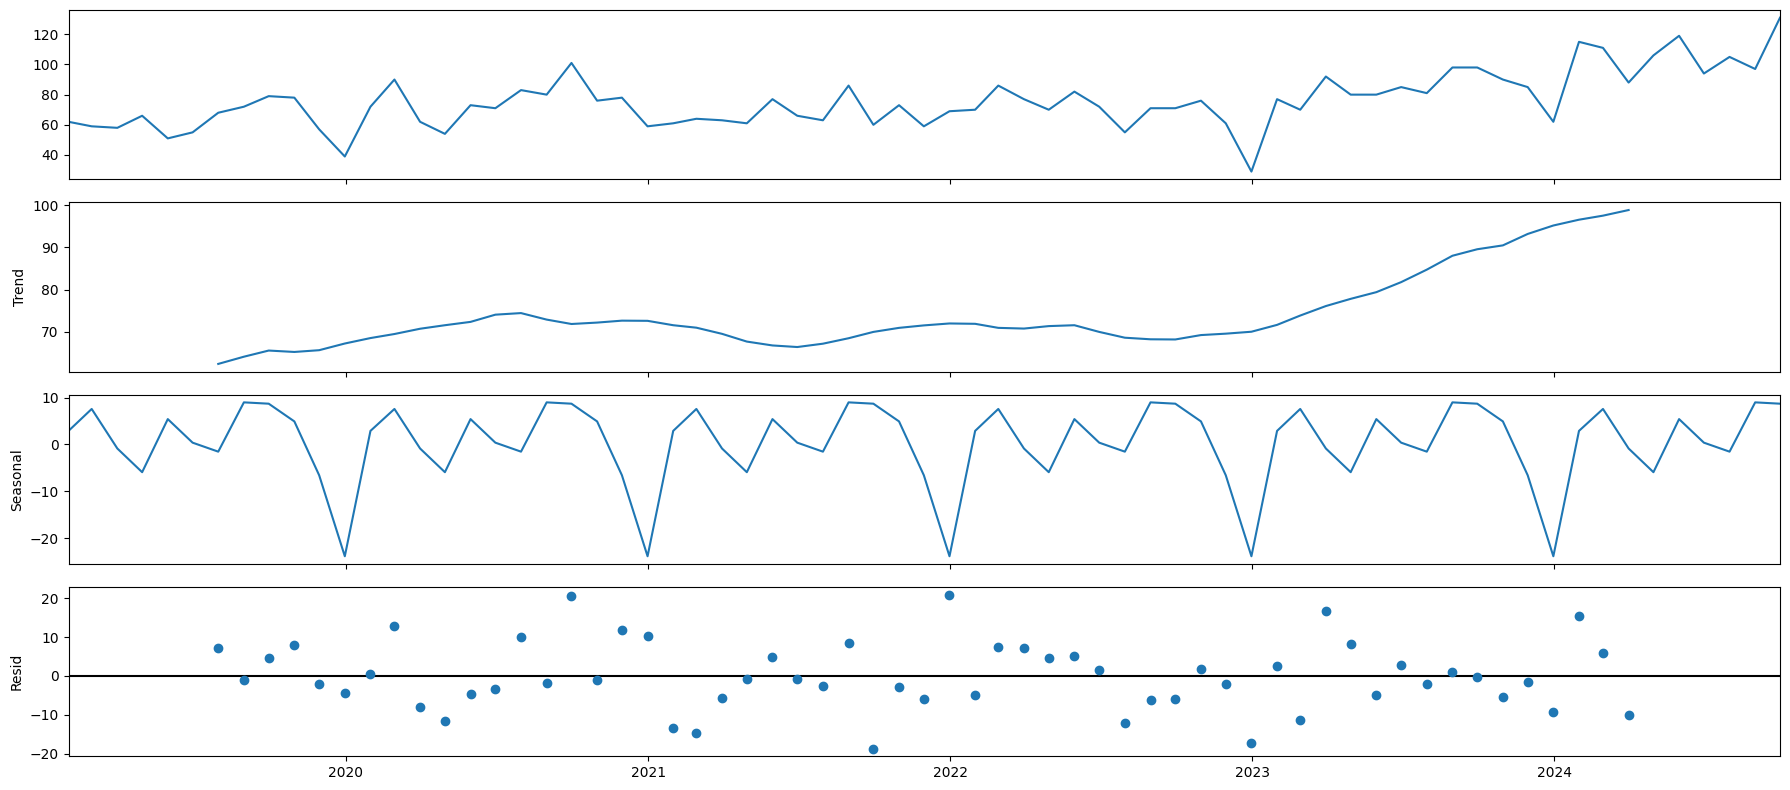

El analisis de los 4 componentes de la serie de tiempo nos evidencia la estacionalidad y la tendencia marcada de la serie.

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

pyplot.figure()
pyplot.subplot(211)
plot_acf(y.Venta, ax=pyplot.gca(), lags = 10)
pyplot.subplot(212)
plot_pacf(y.Venta, ax=pyplot.gca(), lags = 10)
pyplot.show()

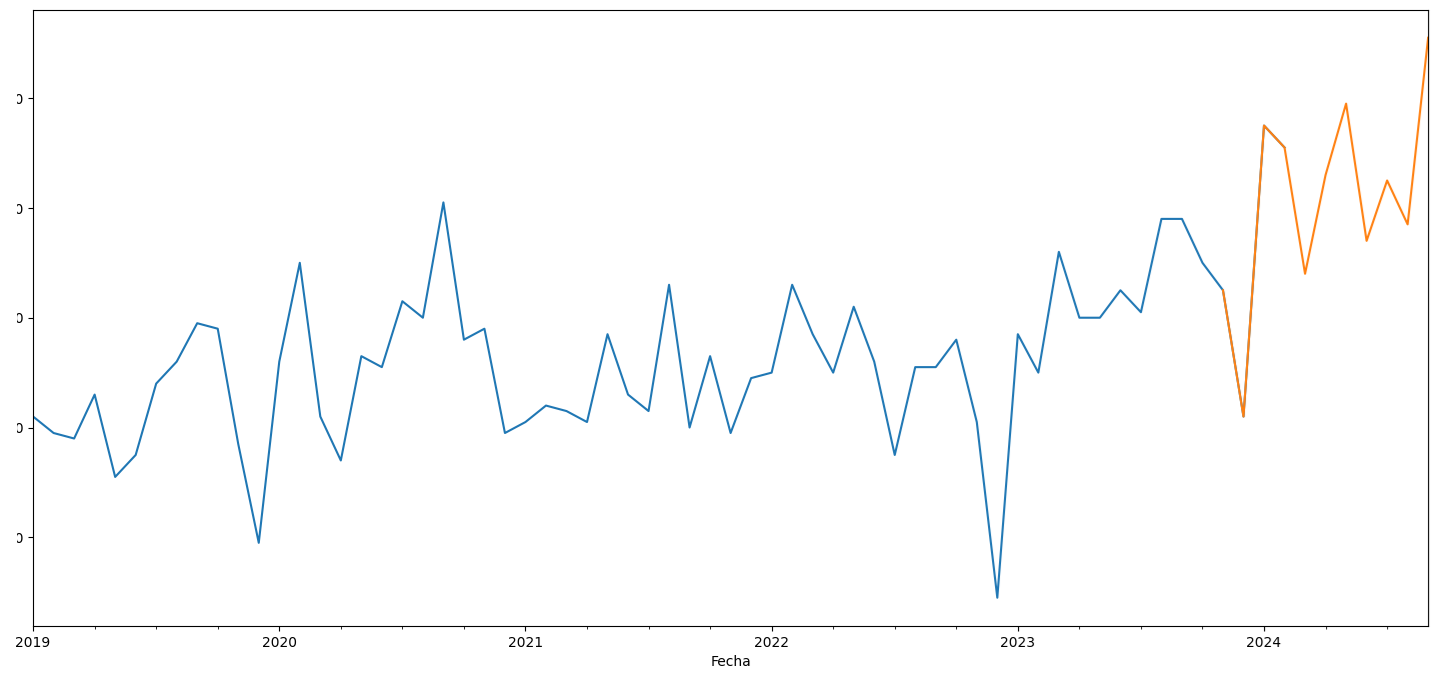

Division de la muestra de entrenamiento y prueba.

In [ ]:
#divide into train and validation set
train = y[:int(0.90*(len(y)))]
valid = y[int(0.85*(len(y))):]

#plotting the data
train['Venta'].plot()
valid['Venta'].plot()
plt.show()

In [ ]:
print(train.shape)
print(valid.shape)

Dunrante la modelizacion de los datos se pobaron muchos algoritmos (PHOPHET,AUTO ARIMA + GRIDSEARCH) y suavizaciones, en este Notebook solo se mostrara el modelo final con mejor ajuste que fue el triple suavizado exponencial.

In [ ]:
# CARGA DE LIBRERIAAS PARA SUAVIZACION
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
import matplotlib.pyplot as plt

In [ ]:
# AJUSTE DEL MODELO
HWES3_ADD = ExponentialSmoothing(y,trend='add',seasonal='add',seasonal_periods=12).fit()
HWES3_MUL = ExponentialSmoothing(y,trend='mul',seasonal='mul',seasonal_periods=12).fit()

HWES3_ADD_fitted = HWES3_ADD.fittedvalues
HWES3_MUL_fitted = HWES3_MUL.fittedvalues
HWES3_ADD_fitted.name = 'Additive TES'
HWES3_MUL_fitted.name = 'multiplicative TES'
pd.concat([y, HWES3_ADD_fitted, HWES3_MUL_fitted], axis=1).plot(title='Triple Exponential Smoothing: Additive and Multiplicative Trend');

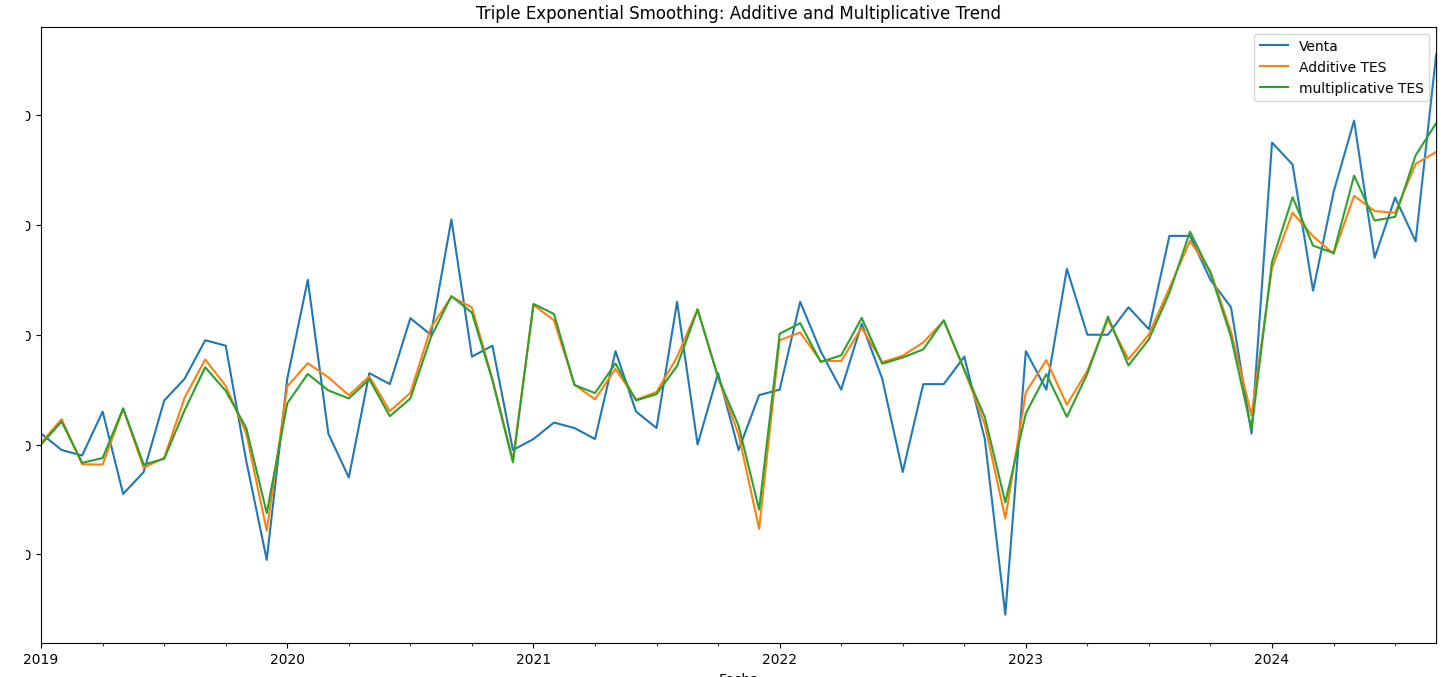

In [ ]:
# RESULTADOS DE BONDAD DE AJUSTE
results = pd.DataFrame(
    index=["SSE", "AIC", "BIC"])

In [ ]:
# DEFINIR MEDIDAS DE BONDAD DE AJUSTE
results["Triple Exp. - Additive"] =   [HWES3_ADD.sse] + [HWES3_ADD.aic] + [HWES3_ADD.bic]

In [ ]:
# MSE = sse/n 6100/56 = 108.92
results

In [ ]:
# ajuste multiplicativo
pd.concat([y, HWES3_MUL_fitted], axis=1).plot(title='Original and fitted ts');

In [ ]:
# RESUMEN DEL MODELO
HWES3_MUL.summary()

In [ ]:
# HOLT WINTERS
fit1 = ExponentialSmoothing(
    y,
    seasonal_periods=12,
    trend="add",
    seasonal="add",
    initialization_method="estimated",
).fit()

fit2 = ExponentialSmoothing(
    y,
    seasonal_periods=12,
    trend="add",
    seasonal="mul",
    initialization_method="estimated",
).fit()

fit3 = ExponentialSmoothing(
    y,
    seasonal_periods=12,
    trend="mul",
    seasonal="add",
    initialization_method="estimated",
).fit()

fit4 = ExponentialSmoothing(
    y,
    seasonal_periods=12,
    trend="mul",
    seasonal="mul",
    initialization_method="estimated",
).fit()

In [ ]:
results2 = pd.DataFrame(
    index=["SSE", "AIC", "BIC"])

In [ ]:
results2["Holt Trend-Add Seas-Add"] = [fit1.sse] + [fit1.aic] + [fit1.bic]
results2["Holt Trend-Add Seas-Mul"] = [fit2.sse] + [fit2.aic] + [fit2.bic]
results2["Holt Trend-Mul Seas-Add"] = [fit3.sse] + [fit3.aic] + [fit3.bic]
results2["Holt Trend-Mul Seas-Mul"] = [fit4.sse] + [fit4.aic] + [fit4.bic]

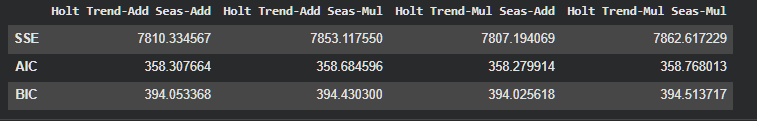

De acuerdo a las metricas de bondad de ajuste el modelo que mejor se ajusta a los datos es el modelo holt winters con tendencia multiplicativa y estacionalidad multiplicativa lo que se ajusta a lo observado en el analisis previo.

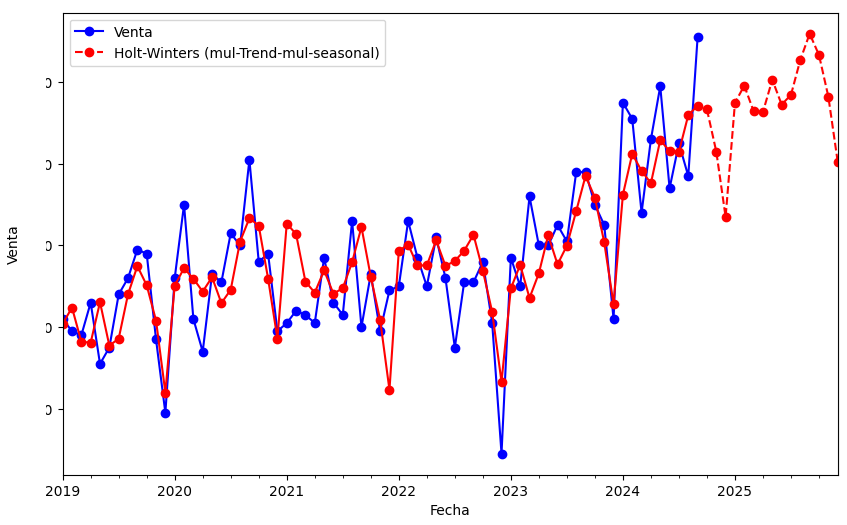

In [ ]:
results2

In [ ]:
HWES3_MUL_fitted.tail()

In [ ]:
from google.colab import files
files.download('hey.xlsx')

In [ ]:
# Exportado a Excel el pronostico para el año 2025
HWES3_MUL_fitted
writer = pd.ExcelWriter('hey1.xlsx')
HWES3_MUL_fitted.to_excel(writer)
writer.save()
files.download('hey1.xlsx')

Este modelo pudo resolver el problema de tener proyecciones de ventas totalmente imprecisas y al realizar la caracterizacion (por precio,region,plan etc) el modelo pudo ser desglosado en cada aspecto de la venta para poder presentarlo a gerencia.